# 1. Problem Definition & Data Assembly

### 1.1. Problem Definition

The goal of this project is to build and train a model that accurately classifies handwritten digits from the MNIST dataset. This is a **multiclass classification problem**. The model will be built using Dense and Dropout layers, adhering to the principles outlined in Chapters 1-4 of "Deep Learning with Python" (DLWP).

*   **Input Data:** The input data consists of grayscale images of handwritten digits. Each image is 28x28 pixels, with pixel values ranging from 0 to 255.
*   **Output Data:** The output is a classification of the input image into one of ten classes, representing the digits 0 through 9.

### 1.2. Data Description

The MNIST dataset consists of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is grayscale and 28x28 pixels in size. The task is a multiclass classification problem, where the model must assign each image to one of ten classes (the digits 0 through 9). The dataset is conveniently available through the Keras API.

In [1]:
# Force tensorflow to use CPU since we are using only the relatively simple techniques
import os
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
# Hide GPU from visible devices
tf.config.set_visible_devices([], 'GPU')

from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)
print("Train labels:", train_labels)

2025-03-10 01:58:53.192614: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-10 01:58:53.193202: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 01:58:53.195422: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-10 01:58:53.201370: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741543133.210904  103864 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741543133.21

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Train labels: [5 0 4 ... 5 6 8]


2025-03-10 01:58:54.688936: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-03-10 01:58:54.688970: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: nemesis
2025-03-10 01:58:54.688977: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: nemesis
2025-03-10 01:58:54.689024: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2025-03-10 01:58:54.689053: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 570.124.4


### 1.3. Data Hypotheses

*   **Hypothesis 1:** The output (digit class) can be predicted from the input (pixel values of the image).  This is a reasonable hypothesis given the nature of the MNIST dataset, as the pixel patterns in the images are visually indicative of the digit being represented.
*   **Hypothesis 2:** The available data is informative enough to learn the relationship between the inputs and outputs.  The MNIST dataset is sufficiently large and well-structured for a deep learning model to learn the underlying patterns.

### 1.4. Environment Setup

This section outlines the necessary libraries and dependencies required to execute the code in this notebook.

*   **Python:** Version 3.6 or higher
*   **TensorFlow:** Version 2.0 or higher (with Keras API)
*   **NumPy:** For numerical operations

In [2]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.18.0
NumPy version: 2.0.2


### 1.5. Data Loading and Exploration

Here, we load the MNIST dataset using the Keras API and explore its structure and properties. We will also examine the class distribution and visualize sample images.

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Train labels: [5 0 4 ... 5 6 8]


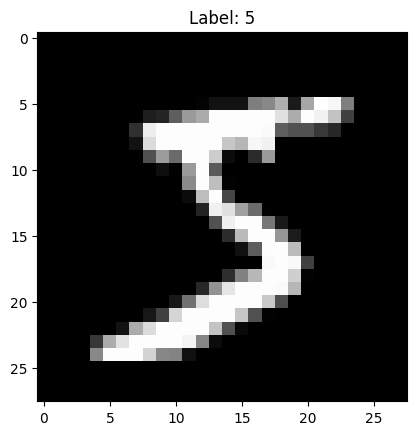

In [3]:
# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Print dataset information
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)
print("Train labels:", train_labels)

# Display the first image
import matplotlib.pyplot as plt
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

### 1.6. Data Preprocessing

This section covers the steps required to prepare the data for training, including reshaping and normalizing the pixel values. Normalizing the pixel values to a range between 0 and 1 helps the model train faster and more effectively.

In [4]:
# Reshape the images to flatten them into vectors
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255


from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


print("Reshaped train images shape:", train_images.shape)
print("Reshaped test images shape:", test_images.shape)
print("Example train label (one-hot encoded):", train_labels[0])

Reshaped train images shape: (60000, 784)
Reshaped test images shape: (10000, 784)
Example train label (one-hot encoded): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### 1.7. Creating a Validation Set

To properly evaluate our model during training and prevent overfitting, we'll create a validation set by splitting the training data. We'll use 10,000 images from the training set for validation and keep the remaining 50,000 for training.

In [5]:
# Creating a validation set
x_val = train_images[:10000]
partial_x_train = train_images[10000:]

y_val = train_labels[:10000]
partial_y_train = train_labels[10000:]

print("Partial training images shape:", partial_x_train.shape)
print("Validation images shape:", x_val.shape)
print("Partial training labels shape:", partial_y_train.shape)
print("Validation labels shape:", y_val.shape)

Partial training images shape: (50000, 784)
Validation images shape: (10000, 784)
Partial training labels shape: (50000, 10)
Validation labels shape: (10000, 10)


### 1.8. Addressing Potential Data Issues

While the MNIST dataset is relatively clean, it's important to consider potential issues that might arise in real-world datasets and how we would address them.

*   **Missing Data:** In the event of missing pixel values (which is unlikely in MNIST), we could consider techniques such as:
    *   **Mean/Median Imputation:** Replacing missing values with the mean or median pixel value across the dataset.
    *   **More Sophisticated Imputation:** Using machine learning models to predict missing values based on other features.

*   **Data Imbalance:** Although the class distribution in MNIST is relatively balanced, if we encountered a significant class imbalance (e.g., many more images of one digit than others), we could employ strategies such as:
    *   **Weighted Loss Functions:** Assigning higher weights to under-represented classes during training.
    *   **Oversampling:** Duplicating samples from under-represented classes.
    *   **Undersampling:** Removing samples from over-represented classes.

*   **Outliers:** While unlikely, outlier pixel values (e.g., extremely bright or dark pixels) could potentially affect model performance. We could consider:
    *   **Clipping:** Limiting pixel values to a specific range.
    *   **Robust Scaling:** Using scaling methods that are less sensitive to outliers (e.g., using quantiles).

These considerations ensure a more robust and adaptable approach to data preprocessing, even though they may not be strictly necessary for the MNIST dataset.

### 2. Choosing a Measure of Success

For this multiclass classification problem (MNIST digit recognition), we will use the following metrics to measure the success of our model:

*   **Primary Metric: Accuracy** - This represents the percentage of correctly classified digits. Given the relatively balanced class distribution in the MNIST dataset, accuracy provides a clear and intuitive measure of overall performance.

*   **Secondary Metric: Categorical Cross-Entropy (Loss Function)** - This loss function measures the difference between the predicted probability distribution and the true distribution of digit classes. Monitoring the categorical cross-entropy during training helps us understand how well the model is learning to predict the probabilities for each digit.

*   **Tertiary Metric: AUC-ROC (Area Under the Receiver Operating Characteristic curve)** - This metric will be computed using "One-vs-Rest" or "OvR" which involves computing the AUC for each class against the rest and then averaging the results. It can be useful to measure how well the model distinguishes each digit class from the others.

In [6]:
# Example usage
import tensorflow as tf

# Define the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),  # Explicitly define the input shape
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model specifying the metrics we want as our measure of success
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.AUC(curve='ROC', name='auc')])

### 3. Deciding on an Evaluation Protocol

#### 3.1. Using a Hold-Out Validation Set

For this project, we'll use a **hold-out validation set** to evaluate our model during training. This involves setting aside a portion of the training data as a validation set, which will be used to monitor the model's performance on unseen data and prevent overfitting.

**Why Hold-out Validation?**

*   The MNIST dataset is of moderate size (60,000 training images), making the hold-out validation approach suitable.
*   It's computationally efficient compared to K-fold cross-validation.
*   It provides a reliable estimate of the model's generalization performance if the validation set is representative of the overall data.

**Creating the Validation Set:**

We've already created the validation set during the data preprocessing phase. We split the original training data into two parts:
*   A partial training set (50,000 images) used for training the model.
*   A validation set (10,000 images) used for evaluating the model's performance during training.

This approach ensures that the model is evaluated on data it hasn't seen during training, providing a more realistic estimate of its ability to generalize to new, unseen data.

**Rationale**

A critical step is to avoid contaminating the training process with the validation data. Thus, the validation data is *only* to be used during model.fit, and for nothing else. By observing how the model performs with data it has not seen, one can observe "overfitting", which is when the model learns the training set a bit too well, and is therefore not performing as well as expected in the validation data. Once the validation performance starts to decrease (or stagnate), this is a good indication that the model is starting to overfit to the training data, and it is time to stop.

In [7]:
# Example usage
import tensorflow as tf

# Define the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),  # Explicitly define the input shape
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model specifying the metrics we want as our measure of success
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.AUC(curve='ROC', name='auc')])

# Train the model, using the validation data for validation
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=10,
                    batch_size=128,
                    validation_data=(x_val, y_val))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8192 - auc: 0.9724 - loss: 0.6429 - val_accuracy: 0.9424 - val_auc: 0.9963 - val_loss: 0.2052
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9362 - auc: 0.9958 - loss: 0.2203 - val_accuracy: 0.9558 - val_auc: 0.9972 - val_loss: 0.1562
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9547 - auc: 0.9976 - loss: 0.1536 - val_accuracy: 0.9616 - val_auc: 0.9979 - val_loss: 0.1278
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9607 - auc: 0.9982 - loss: 0.1275 - val_accuracy: 0.9695 - val_auc: 0.9984 - val_loss: 0.1060
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9666 - auc: 0.9986 - loss: 0.1108 - val_accuracy: 0.9697 - val_auc: 0.9981 - val_loss: 0.1029
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9729 - auc: 0.9987 - loss: 0.0928 - val_accuracy: 0.9727 - val_auc: 0.9983 - val_loss: 0.0933
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 

#### 3.2. Using the `history` Object

The `model.fit()` method returns a `history` object that contains a record of training metrics (loss, accuracy, etc.) at each epoch. This object is extremely useful for visualizing the training process and identifying potential issues such as overfitting or underfitting.

We can use the `history` object to plot the training and validation loss and accuracy curves, which will help us determine how well the model is learning and whether it's generalizing to the validation data.

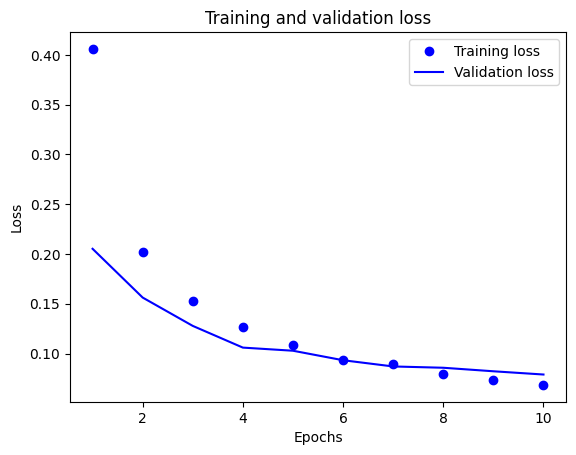

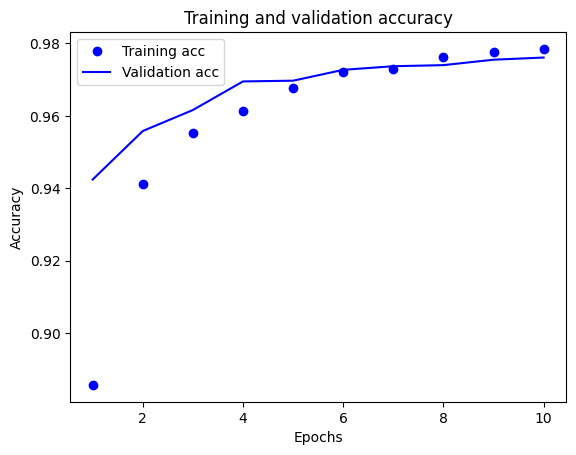

In [8]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()   # clear figure

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#### 3.3. Limitations of Hold-out Validation

It's important to acknowledge that hold-out validation has limitations:

*   **Sensitivity to Data Split:** The performance of the model can be sensitive to the specific split of data into training and validation sets. If the validation set isn't representative of the overall data distribution, the evaluation results might be misleading.
*   **Doesn't Utilize All Data for Training:**  A portion of the data is held out for validation, which means that the model is trained on less data than is available. This can be a disadvantage when the dataset is small.

**When to Consider Other Evaluation Protocols:**

*   **Small Datasets:**  K-fold cross-validation is generally preferred for small datasets, as it allows the model to be trained and evaluated on all of the data.
*   **Non-Stationary Data:** For time-series data or data where the distribution changes over time, more sophisticated evaluation techniques like time-series cross-validation are necessary.

Partial training images shape: (50000, 784)
Validation images shape: (10000, 784)
Partial training labels shape: (50000, 10)
Validation labels shape: (10000, 10)
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8167 - auc: 0.9726 - loss: 0.6433 - val_accuracy: 0.9393 - val_auc: 0.9961 - val_loss: 0.2138
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9368 - auc: 0.9957 - loss: 0.2192 - val_accuracy: 0.9566 - val_auc: 0.9977 - val_loss: 0.1506
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9549 - auc: 0.9973 - loss: 0.1588 - val_accuracy: 0.9626 - val_auc: 0.9980 - val_loss: 0.1276
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9618 - auc: 0.9979 - loss: 0.1307 - val_accuracy: 0.9650 - val_auc: 0.9981 - val_loss: 0.1152
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9677 - auc: 0.9983 - loss: 0.1098 - val_accuracy: 0.9686 - val_auc: 0.9984 - val_loss: 0.1020
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━

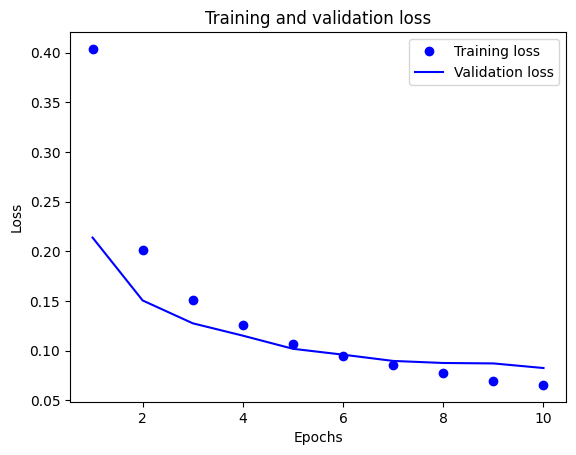

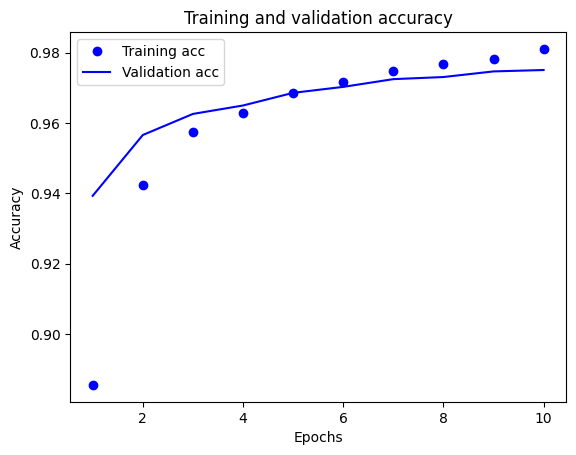

In [9]:
import numpy as np

# Set a random seed for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Shuffle the training data
indices = np.arange(train_images.shape[0])
np.random.shuffle(indices)
train_images = train_images[indices]
train_labels = train_labels[indices]


# Creating a validation set
x_val = train_images[:10000]
partial_x_train = train_images[10000:]

y_val = train_labels[:10000]
partial_y_train = train_labels[10000:]

print("Partial training images shape:", partial_x_train.shape)
print("Validation images shape:", x_val.shape)
print("Partial training labels shape:", partial_y_train.shape)
print("Validation labels shape:", y_val.shape)

# Example usage
import tensorflow as tf

# Define the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(784,)),  # Explicitly define the input shape
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model specifying the metrics we want as our measure of success
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.AUC(curve='ROC', name='auc')])

# Train the model, using the validation data for validation
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=10,
                    batch_size=128,
                    validation_data=(x_val, y_val))

import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf()   # clear figure

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### 4. Data Preparation

This section details the steps involved in preparing the MNIST data for ingestion into our neural network. This includes:

*   Reshaping the image data into a suitable format.
*   Scaling pixel values to a range that is beneficial for training.
*   Discussing considerations for other data preparation steps that might be needed for more complex datasets.

#### 4.1. Reshaping the Image Data

Neural networks typically expect input data to be in a specific format. For Dense layers, we need to flatten the 2D image data (28x28 pixels) into a 1D vector (784 elements).

In [10]:
# Reshape the images to flatten them into vectors
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))

print("Reshaped train images shape:", train_images.shape)
print("Reshaped test images shape:", test_images.shape)

Reshaped train images shape: (60000, 784)
Reshaped test images shape: (10000, 784)


#### 4.2. Scaling Pixel Values

Pixel values in the MNIST dataset range from 0 to 255. It's generally good practice to scale these values to a smaller range, such as 0 to 1. This helps the neural network learn more efficiently. We achieve this by dividing each pixel value by the maximum possible value (255).  We also cast to `float32` for better precision.

In [11]:
# Scale pixel values to the range [0, 1]
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

print("Train images data type:", train_images.dtype)
print("Test images data type:", test_images.dtype)
print("First 5 values of the first train image:", train_images[0,:5])

Train images data type: float32
Test images data type: float32
First 5 values of the first train image: [0. 0. 0. 0. 0.]


#### 4.3. One-Hot Encoding the Labels

The labels in the MNIST dataset represent the digit class (0 to 9). For multiclass classification, it's common to use one-hot encoding, where each label is converted into a vector of zeros except for a 1 at the index corresponding to the digit class. Keras provides the `to_categorical` function for this purpose.

In [12]:
from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

print("Train labels shape:", train_labels.shape)
print("Test labels shape:", test_labels.shape)
print("Example train label (one-hot encoded):", train_labels[0])

Train labels shape: (60000, 10, 2)
Test labels shape: (10000, 10, 2)
Example train label (one-hot encoded): [[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]
